In [27]:
import sys
import os

sys.path.append(os.path.abspath('../src'))

from preprocess import load_data, split_data
import shap
import joblib
import pandas as pd
import matplotlib.pyplot as plt

In [28]:
pipeline = joblib.load('../models/model.pkl')
df = load_data('../data/insurance.csv')
X_train, X_test, y_train, y_test = split_data(df)

In [29]:
preprocessor = pipeline.named_steps['preprocessor']
cat_encoder = preprocessor.named_transformers_['cat']
all_feature_names = ['age', 'bmi', 'children'] + list(cat_encoder.get_feature_names_out())

In [32]:
X_test_transformed = preprocessor.transform(X_test)
X_test_df = pd.DataFrame(X_test_transformed, columns=all_feature_names)

In [33]:
model = pipeline.named_steps['regressor']
explainer = shap.Explainer(model.predict, X_test_df)
shap_values = explainer(X_test_df)

ExactExplainer explainer: 269it [00:14, 17.87it/s]                          


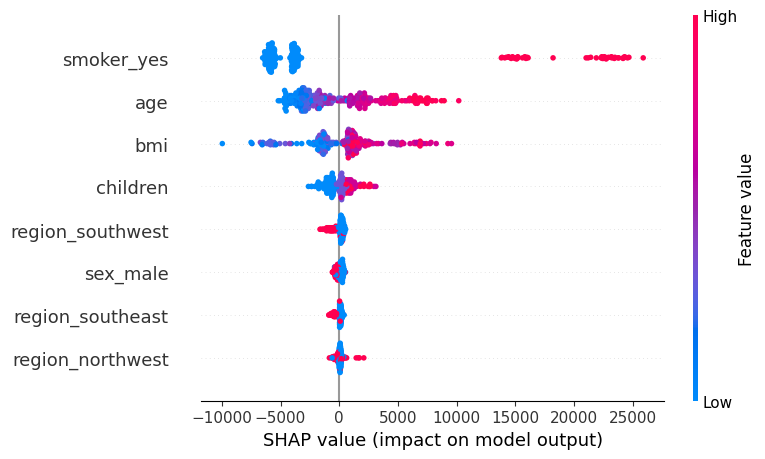

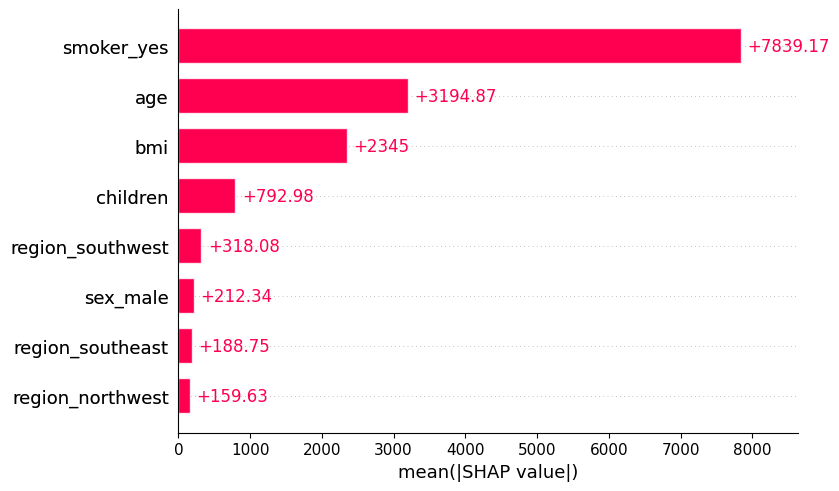

In [34]:
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_df)

plt.figure(figsize=(10, 6))
shap.plots.bar(shap_values)